# 🗑️ Karachi Municipal Solid Waste – Data Mining Pipeline
### Full pipeline: Load → Preprocess → EDA → Feature Engineering → Models → Evaluation

In [1]:
# Run this cell first — installs everything you need
# !pip install pandas numpy matplotlib seaborn scikit-learn

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.cluster import KMeans

import warnings
warnings.filterwarnings('ignore')

# ── Create folder to save all figures ──────────────────────
os.makedirs('figures', exist_ok=True)
print('✅ All libraries imported successfully!')
print('📁 figures/ folder ready')

✅ All libraries imported successfully!
📁 figures/ folder ready


In [2]:
df = pd.read_csv(r'C:\Users\HAMZA PC\Downloads\research\Karachi_Research_Dataset.csv')
print(f'Rows: {df.shape[0]}  |  Columns: {df.shape[1]}')
print(f'Column names: {df.columns.tolist()}')
df.head()

Rows: 60  |  Columns: 11
Column names: ['Date', 'Year', 'Population', 'Total_MSW_Tons_Month', 'Plastic_Percentage', 'Plastic_Waste_Tons', 'Generation_Rate_kg_capita_day', 'Is_Monsoon', 'Is_Event', 'Moisture_Content_Percentage', 'Waste_Density_kg_m3']


,Date,Year,Population,Total_MSW_Tons_Month,Plastic_Percentage,Plastic_Waste_Tons,Generation_Rate_kg_capita_day,Is_Monsoon,Is_Event,Moisture_Content_Percentage,Waste_Density_kg_m3
0,2020-01-01,2020,16094000,273404.87,0.1665,45521.71,0.5480,0,0,48.69,385.83
1,2020-02-01,2020,16127126,256292.29,0.1606,41166.20,0.5480,0,0,48.04,370.44
2,2020-03-01,2020,16160321,274531.53,0.1579,43334.98,0.5480,0,0,47.27,377.32
3,2020-04-01,2020,16193585,266222.54,0.1656,44086.45,0.5480,0,0,48.77,375.22
4,2020-05-01,2020,16226916,303229.13,0.1635,49577.65,0.6028,0,1,47.85,385.58


In [3]:
# Convert Date column to datetime
df['Date'] = pd.to_datetime(df['Date'])

# Extract Month and Quarter from Date
df['Month']   = df['Date'].dt.month
df['Quarter'] = df['Date'].dt.quarter

# Check for missing values
print('Missing Values:')
print(df.isnull().sum())

print('\nData Types:')
print(df.dtypes)

Missing Values:
Date                             0
Year                             0
Population                       0
Total_MSW_Tons_Month             0
Plastic_Percentage               0
Plastic_Waste_Tons               0
Generation_Rate_kg_capita_day    0
Is_Monsoon                       0
Is_Event                         0
Moisture_Content_Percentage      0
Waste_Density_kg_m3              0
Month                            0
Quarter                          0
dtype: int64

Data Types:
Date                             datetime64[ns]
Year                                      int64
Population                                int64
Total_MSW_Tons_Month                    float64
Plastic_Percentage                      float64
Plastic_Waste_Tons                      float64
Generation_Rate_kg_capita_day           float64
Is_Monsoon                                int64
Is_Event                                  int64
Moisture_Content_Percentage             float64
Waste_Density_kg_m3    

In [4]:
df.describe().round(2)

,Date,Year,Population,Total_MSW_Tons_Month,Plastic_Percentage,Plastic_Waste_Tons,Generation_Rate_kg_capita_day,Is_Monsoon,Is_Event,Moisture_Content_Percentage,Waste_Density_kg_m3,Month,Quarter
count,60,60.00,60.00,60.00,60.00,60.00,60.00,60.00,60.00,60.00,60.00,60.00,60.00
mean,2022-06-16 15:12:00,2022.00,17111296.75,299392.34,0.16,48367.94,0.57,0.25,0.17,50.11,385.47,6.50,2.50
min,2020-01-01 00:00:00,2020.00,16094000.00,255950.63,0.16,40491.79,0.55,0.00,0.00,47.01,370.07,1.00,1.00
25%,2021-03-24 06:00:00,2021.00,16589602.25,279144.15,0.16,45027.58,0.55,0.00,0.00,47.56,375.58,3.75,1.75
50%,2022-06-16 00:00:00,2022.00,17100461.50,297142.56,0.16,47380.82,0.56,0.00,0.00,48.35,382.14,6.50,2.50
75%,2023-09-08 12:00:00,2023.00,17627048.00,312994.60,0.16,51147.44,0.57,0.25,0.00,54.01,387.53,9.25,3.25
max,2024-12-01 00:00:00,2024.00,18169845.00,382272.27,0.17,61673.80,0.71,1.00,1.00,60.59,428.52,12.00,4.00
std,NaN,1.43,614393.75,27129.80,0.00,4381.78,0.04,0.44,0.38,3.82,14.85,3.48,1.13


## 📈 Figure 1 – Total Waste Over Time

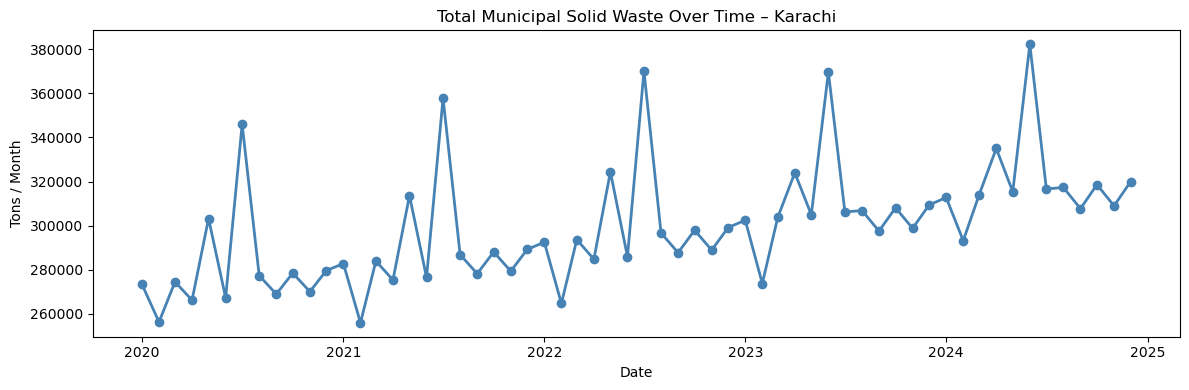

✅ Fig 1 saved


In [5]:
plt.figure(figsize=(12, 4))
plt.plot(df['Date'], df['Total_MSW_Tons_Month'], marker='o', color='steelblue', linewidth=2)
plt.title('Total Municipal Solid Waste Over Time – Karachi')
plt.xlabel('Date')
plt.ylabel('Tons / Month')
plt.tight_layout()
plt.savefig('figures/fig1_waste_over_time.png', dpi=300, bbox_inches='tight')  # ← ADDED
plt.show()
print('✅ Fig 1 saved')

## 🔥 Figure 2 – Correlation Heatmap

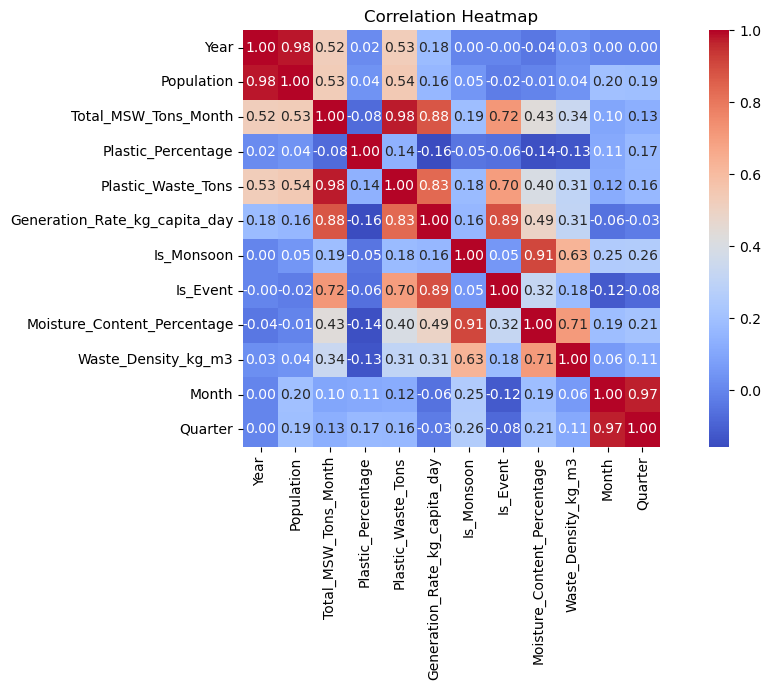

✅ Fig 2 saved


In [6]:
plt.figure(figsize=(11, 7))
corr = df.drop(columns=['Date']).corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.savefig('figures/fig2_correlation_heatmap.png', dpi=300, bbox_inches='tight')  # ← ADDED
plt.show()
print('✅ Fig 2 saved')

## 🌧️ Figure 3 – Monsoon vs Non-Monsoon Waste

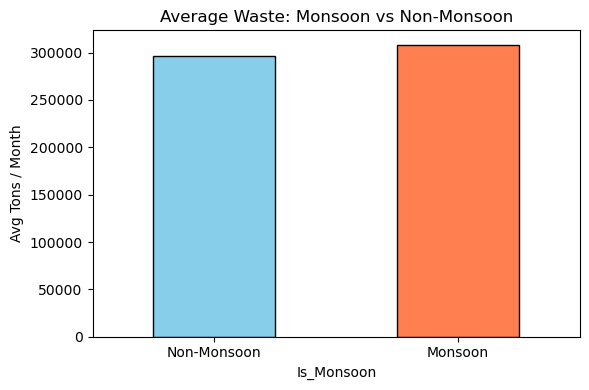

✅ Fig 3 saved


In [7]:
plt.figure(figsize=(6, 4))
df.groupby('Is_Monsoon')['Total_MSW_Tons_Month'].mean().plot(
    kind='bar', color=['skyblue', 'coral'], edgecolor='black'
)
plt.xticks([0, 1], ['Non-Monsoon', 'Monsoon'], rotation=0)
plt.title('Average Waste: Monsoon vs Non-Monsoon')
plt.ylabel('Avg Tons / Month')
plt.tight_layout()
plt.savefig('figures/fig3_monsoon_vs_nonmonsoon.png', dpi=300, bbox_inches='tight')  # ← ADDED
plt.show()
print('✅ Fig 3 saved')

## 🧴 Figure 4 – Plastic Waste Per Month

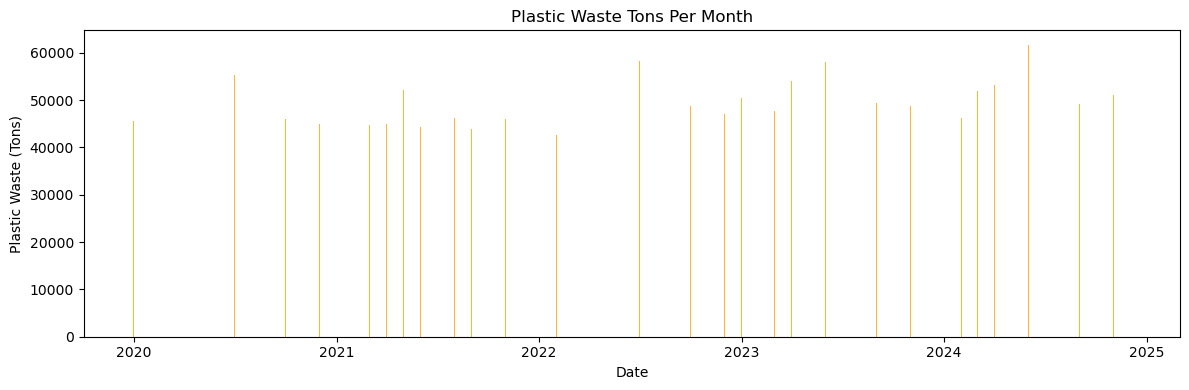

✅ Fig 4 saved


In [8]:
plt.figure(figsize=(12, 4))
plt.bar(df['Date'], df['Plastic_Waste_Tons'], color='orange', alpha=0.8)
plt.title('Plastic Waste Tons Per Month')
plt.xlabel('Date')
plt.ylabel('Plastic Waste (Tons)')
plt.tight_layout()
plt.savefig('figures/fig4_plastic_waste.png', dpi=300, bbox_inches='tight')  # ← ADDED
plt.show()
print('✅ Fig 4 saved')

In [9]:
# Create 3 new meaningful features
df['Waste_Per_Capita']       = df['Total_MSW_Tons_Month'] / df['Population'] * 1000
df['Plastic_to_Total_Ratio'] = df['Plastic_Waste_Tons']   / df['Total_MSW_Tons_Month']
df['Is_Summer']              = df['Month'].apply(lambda m: 1 if m in [5, 6, 7] else 0)

print('New features added: Waste_Per_Capita, Plastic_to_Total_Ratio, Is_Summer')
df[['Waste_Per_Capita', 'Plastic_to_Total_Ratio', 'Is_Summer']].head()

New features added: Waste_Per_Capita, Plastic_to_Total_Ratio, Is_Summer


,Waste_Per_Capita,Plastic_to_Total_Ratio,Is_Summer
0,16.9880,0.166499,0
1,15.8920,0.160622,0
2,16.9880,0.157851,0
3,16.4400,0.165600,0
4,18.6868,0.163499,1


In [10]:
TARGET = 'Total_MSW_Tons_Month'

FEATURES = [
    'Population', 'Generation_Rate_kg_capita_day',
    'Is_Monsoon', 'Is_Event', 'Moisture_Content_Percentage',
    'Waste_Density_kg_m3', 'Month', 'Quarter',
    'Waste_Per_Capita', 'Is_Summer'
]

X = df[FEATURES]
y = df[TARGET]

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f'Features shape : {X.shape}')
print(f'Target shape   : {y.shape}')

Features shape : (60, 10)
Target shape   : (60,)


In [11]:
lr = LinearRegression()

lr_r2   = cross_val_score(lr, X_scaled, y, cv=5, scoring='r2').mean()
lr_mae  = -cross_val_score(lr, X_scaled, y, cv=5, scoring='neg_mean_absolute_error').mean()
lr_rmse = np.sqrt(-cross_val_score(lr, X_scaled, y, cv=5, scoring='neg_mean_squared_error').mean())

print('Linear Regression – 5-Fold Cross Validation')
print(f'  R²   : {lr_r2:.4f}')
print(f'  MAE  : {lr_mae:.2f} tons')
print(f'  RMSE : {lr_rmse:.2f} tons')

Linear Regression – 5-Fold Cross Validation
  R²   : 0.9984
  MAE  : 615.16 tons
  RMSE : 880.55 tons


## 📊 Figure 5 – Linear Regression Coefficients

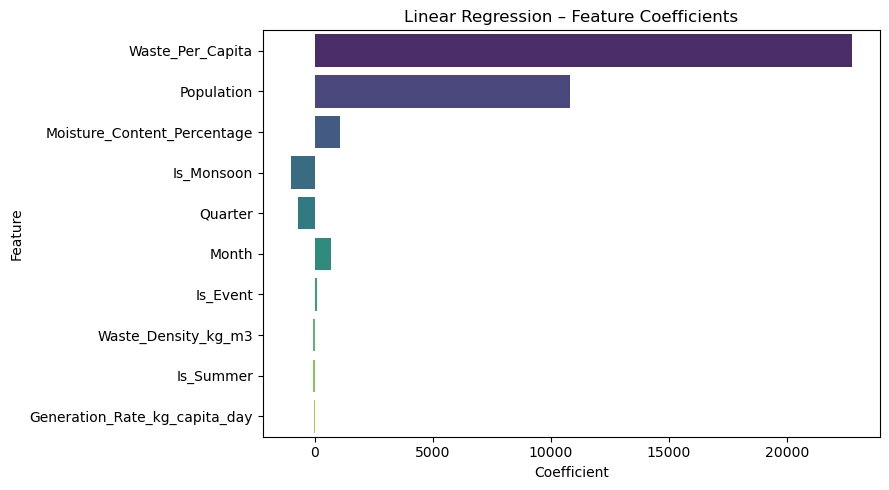

✅ Fig 5 saved


In [12]:
lr.fit(X_scaled, y)

coef_df = pd.DataFrame({'Feature': FEATURES, 'Coefficient': lr.coef_})
coef_df = coef_df.reindex(coef_df['Coefficient'].abs().sort_values(ascending=False).index)

plt.figure(figsize=(9, 5))
sns.barplot(data=coef_df, x='Coefficient', y='Feature', palette='viridis')
plt.title('Linear Regression – Feature Coefficients')
plt.tight_layout()
plt.savefig('figures/fig5_lr_coefficients.png', dpi=300, bbox_inches='tight')  # ← ADDED
plt.show()
print('✅ Fig 5 saved')

In [14]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)

rf_r2   = cross_val_score(rf, X, y, cv=5, scoring='r2').mean()
rf_mae  = -cross_val_score(rf, X, y, cv=5, scoring='neg_mean_absolute_error').mean()
rf_rmse = np.sqrt(-cross_val_score(rf, X, y, cv=5, scoring='neg_mean_squared_error').mean())

print('Random Forest – 5-Fold Cross Validation')
print(f'  R²   : {rf_r2:.4f}')
print(f'  MAE  : {rf_mae:.2f} tons')
print(f'  RMSE : {rf_rmse:.2f} tons')

Random Forest – 5-Fold Cross Validation
  R²   : 0.8413
  MAE  : 7656.96 tons
  RMSE : 8775.02 tons


## 📊 Figure 6 – Random Forest Feature Importance

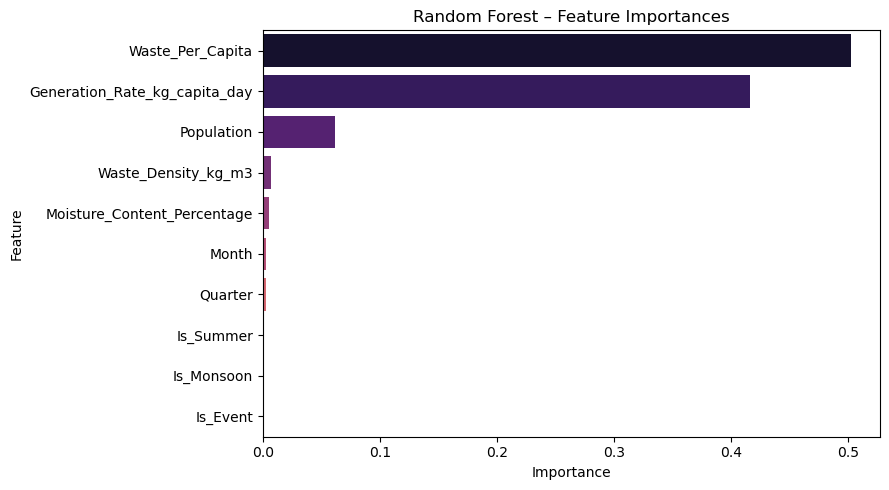

✅ Fig 6 saved


In [15]:
rf.fit(X, y)

imp_df = pd.DataFrame({'Feature': FEATURES, 'Importance': rf.feature_importances_})
imp_df = imp_df.sort_values('Importance', ascending=False)

plt.figure(figsize=(9, 5))
sns.barplot(data=imp_df, x='Importance', y='Feature', palette='magma')
plt.title('Random Forest – Feature Importances')
plt.tight_layout()
plt.savefig('figures/fig6_rf_importances.png', dpi=300, bbox_inches='tight')  # ← ADDED
plt.show()
print('✅ Fig 6 saved')

## 🎯 Figure 7 – Actual vs Predicted (Random Forest)

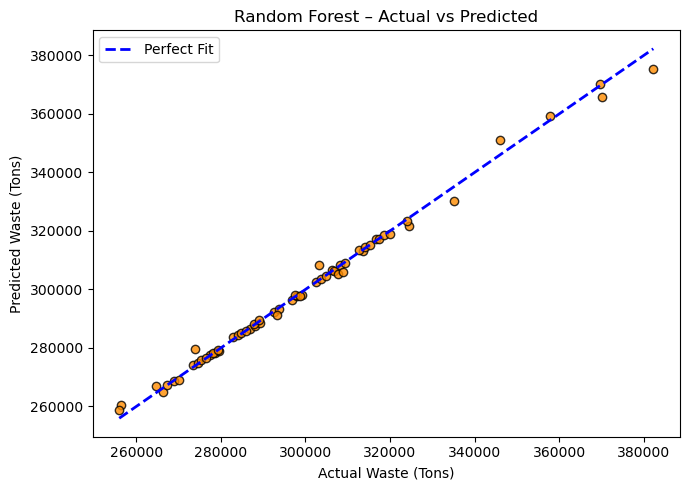

✅ Fig 7 saved


In [16]:
y_pred = rf.predict(X)

plt.figure(figsize=(7, 5))
plt.scatter(y, y_pred, color='darkorange', edgecolors='black', alpha=0.8)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'b--', linewidth=2, label='Perfect Fit')
plt.xlabel('Actual Waste (Tons)')
plt.ylabel('Predicted Waste (Tons)')
plt.title('Random Forest – Actual vs Predicted')
plt.legend()
plt.tight_layout()
plt.savefig('figures/fig7_actual_vs_predicted.png', dpi=300, bbox_inches='tight')  # ← ADDED
plt.show()
print('✅ Fig 7 saved')

## 🔵 Figure 8 – K-Means Elbow Method

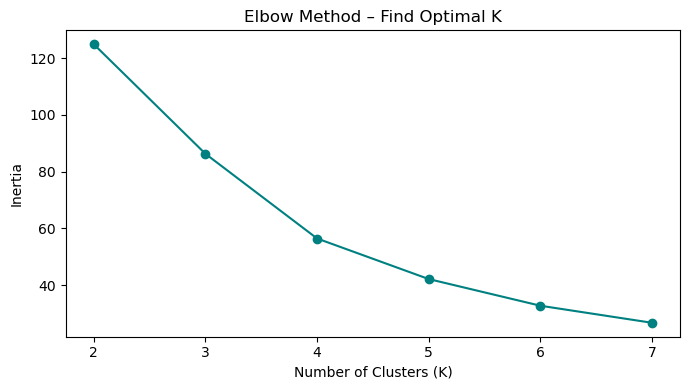

✅ Fig 8 saved


In [17]:
cluster_features = ['Total_MSW_Tons_Month', 'Plastic_Waste_Tons',
                    'Moisture_Content_Percentage', 'Waste_Density_kg_m3']

X_clust = StandardScaler().fit_transform(df[cluster_features])

inertias = []
K_range  = range(2, 8)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_clust)
    inertias.append(km.inertia_)

plt.figure(figsize=(7, 4))
plt.plot(list(K_range), inertias, marker='o', color='teal')
plt.title('Elbow Method – Find Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.tight_layout()
plt.savefig('figures/fig8_elbow_method.png', dpi=300, bbox_inches='tight')  # ← ADDED
plt.show()
print('✅ Fig 8 saved')

## 🔵 Figure 9 – K-Means Clustering (K=3)

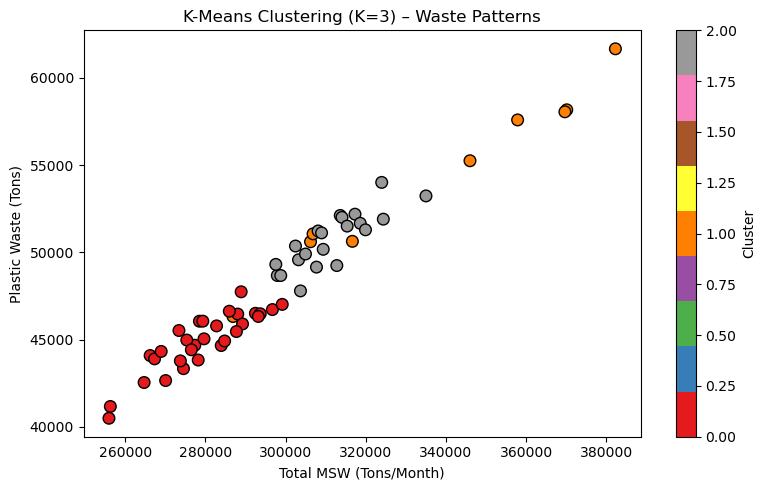

✅ Fig 9 saved
Cluster Sizes:
Cluster
0    30
1     9
2    21
Name: count, dtype: int64


In [18]:
km_final    = KMeans(n_clusters=3, random_state=42, n_init=10)
df['Cluster'] = km_final.fit_predict(X_clust)

plt.figure(figsize=(8, 5))
scatter = plt.scatter(
    df['Total_MSW_Tons_Month'],
    df['Plastic_Waste_Tons'],
    c=df['Cluster'], cmap='Set1', edgecolors='black', s=70
)
plt.colorbar(scatter, label='Cluster')
plt.xlabel('Total MSW (Tons/Month)')
plt.ylabel('Plastic Waste (Tons)')
plt.title('K-Means Clustering (K=3) – Waste Patterns')
plt.tight_layout()
plt.savefig('figures/fig9_kmeans_clusters.png', dpi=300, bbox_inches='tight')  # ← ADDED
plt.show()
print('✅ Fig 9 saved')

print('Cluster Sizes:')
print(df['Cluster'].value_counts().sort_index())

In [19]:
summary = pd.DataFrame({
    'Model'  : ['Linear Regression', 'Random Forest'],
    'R²'     : [round(lr_r2,   4), round(rf_r2,   4)],
    'MAE'    : [round(lr_mae,  2), round(rf_mae,  2)],
    'RMSE'   : [round(lr_rmse, 2), round(rf_rmse, 2)]
})

print('='*45)
print('        MODEL COMPARISON SUMMARY')
print('='*45)
print(summary.to_string(index=False))
print('='*45)
print('K-Means Clustering: 3 clusters found')
print('\n✅ Pipeline Complete!')
print('\n📁 All 9 figures saved in the figures/ folder!')

        MODEL COMPARISON SUMMARY
            Model     R²     MAE    RMSE
Linear Regression 0.9984  615.16  880.55
    Random Forest 0.8413 7656.96 8775.02
K-Means Clustering: 3 clusters found

✅ Pipeline Complete!

📁 All 9 figures saved in the figures/ folder!
